# YOLO Model Training - Tokamak Plasma Detection

Complete pipeline for training YOLOv8 on tokamak plasma detection data.

## 1. Setup and Imports

In [1]:
import sys
import os
import yaml
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch
from tqdm import tqdm

# Add ingestion_program to path
sys.path.insert(0, 'ingestion_program')
from tokam2d_utils import TokamDataset

# Install ultralytics if needed
try:
    from ultralytics import YOLO
    print("✓ Ultralytics YOLO is installed")
except ImportError:
    print("Installing ultralytics...")
    !pip install ultralytics
    from ultralytics import YOLO

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

✓ Ultralytics YOLO is installed

PyTorch version: 2.10.0+cu126
CUDA available: True
CUDA device: Tesla T4


## 2. Configuration

In [2]:
# Paths
DATA_DIR = Path('./dev_phase/input_data/train')
YOLO_DATASET_DIR = Path('./yolo_training_data')
OUTPUT_DIR = Path('./runs')

# Training parameters
CONFIG = {
    # Model
    'model': 'yolov10l.pt',  # nano (fastest), or yolov8s/m/l/x for better accuracy
    
    # Training
    'epochs': 500,
    'batch_size': 4,
    'img_size': 1024,
    'patience': 300,  # Early stopping
    
    # Data split
    'val_split': 0.05,  # 10% for validation
    
    # Hardware
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'workers': 4,
    
    # Optimization
    'optimizer': 'Adam',
    'lr0': 1e-4,
    'weight_decay': 0.0005,
    
    # Augmentation
    'hsv_h': 0.0,
    'hsv_s': 0.0,
    'hsv_v': 0.0,
    'degrees': 20,  # rotation
    'translate': 0.05,
    'scale': 1.0,
    'flipud': 0,
    'fliplr': 0,
    'mosaic': 0.5,
}

print("Training Configuration:")
print("=" * 50)
for key, value in CONFIG.items():
    print(f"  {key:20s}: {value}")
print("=" * 50)

Training Configuration:
  model               : yolov10l.pt
  epochs              : 500
  batch_size          : 4
  img_size            : 1024
  patience            : 300
  val_split           : 0.05
  device              : cuda
  workers             : 4
  optimizer           : Adam
  lr0                 : 0.0001
  weight_decay        : 0.0005
  hsv_h               : 0.0
  hsv_s               : 0.0
  hsv_v               : 0.0
  degrees             : 20
  translate           : 0.05
  scale               : 1.0
  flipud              : 0
  fliplr              : 0
  mosaic              : 0.5


## 3. Load and Analyze Dataset

In [3]:
# Load dataset
print("Loading dataset...")
dataset = TokamDataset(DATA_DIR, include_unlabeled=False)
print(f"Total samples in dataset: {len(dataset)}")

# Find labeled samples
labeled_indices = []
box_counts = []

for idx in range(len(dataset)):
    _, target = dataset[idx]
    if target['boxes'] is not None and len(target['boxes']) > 0:
        labeled_indices.append(idx)
        box_counts.append(len(target['boxes']))

print(f"\nDataset Statistics:")
print(f"  Labeled samples: {len(labeled_indices)}")
print(f"  Total boxes: {sum(box_counts)}")
print(f"  Avg boxes per image: {np.mean(box_counts):.2f}")
print(f"  Min boxes: {min(box_counts)}")
print(f"  Max boxes: {max(box_counts)}")

Loading dataset...
Found annotations for 30 frames in 2 files.
Loaded 30 frames.
Total samples in dataset: 30

Dataset Statistics:
  Labeled samples: 30
  Total boxes: 282
  Avg boxes per image: 9.40
  Min boxes: 1
  Max boxes: 18


## 4. Split Dataset (Train/Val)

In [4]:
# Shuffle and split
np.random.seed(42)
np.random.shuffle(labeled_indices)

val_size = int(len(labeled_indices) * CONFIG['val_split'])
train_indices = labeled_indices[val_size:]
val_indices = labeled_indices[:val_size]

print(f"Dataset Split:")
print(f"  Training: {len(train_indices)} samples ({len(train_indices)/len(labeled_indices)*100:.1f}%)")
print(f"  Validation: {len(val_indices)} samples ({CONFIG['val_split']*100:.1f}%)")
print(f"\nValidation sample indices: {val_indices[:10]}..." if len(val_indices) > 10 else f"\nValidation sample indices: {val_indices}")

Dataset Split:
  Training: 29 samples (96.7%)
  Validation: 1 samples (5.0%)

Validation sample indices: [27]


## 5. Convert to YOLO Format

YOLO requires:
- Images in `images/train/` and `images/val/`
- Labels in `labels/train/` and `labels/val/`
- Label format: `class x_center y_center width height` (normalized 0-1)

In [5]:
def save_yolo_format(dataset, indices, split_name, output_dir):
    """
    Save dataset in YOLO format.
    """
    img_dir = output_dir / 'images' / split_name
    label_dir = output_dir / 'labels' / split_name
    
    img_dir.mkdir(parents=True, exist_ok=True)
    label_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\nProcessing {split_name} set ({len(indices)} samples)...")
    
    for i, idx in enumerate(tqdm(indices, desc=f"{split_name}")):
        image, target = dataset[idx]
        img_np = image.squeeze().cpu().numpy() if hasattr(image, 'cpu') else image.squeeze().numpy()
        
        # Normalize to 0-255
        img_norm = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
        img_uint8 = (img_norm * 255).astype(np.uint8)
        
        # Save image
        img_name = f"{split_name}_{idx:06d}.jpg"
        Image.fromarray(img_uint8).save(img_dir / img_name)
        
        # Save labels
        label_name = f"{split_name}_{idx:06d}.txt"
        label_path = label_dir / label_name
        
        with open(label_path, 'w') as f:
            if target['boxes'] is not None:
                for box in target['boxes']:
                    x, y, w, h = box.cpu().numpy() if hasattr(box, 'cpu') else box.numpy()
                    
                    # Check if already normalized or in pixels
                    img_h, img_w = img_np.shape
                    if x > 1 or y > 1:
                        x, y, w, h = x/img_w, y/img_h, w/img_w, h/img_h
                    
                    # Convert corner to center format
                    x_center = x + w/2
                    y_center = y + h/2
                    
                    # Clamp to [0, 1]
                    x_center = np.clip(x_center, 0, 1)
                    y_center = np.clip(y_center, 0, 1)
                    w = np.clip(w, 0, 1)
                    h = np.clip(h, 0, 1)
                    
                    # Write: class x_center y_center width height
                    f.write(f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

# Clean previous data
if YOLO_DATASET_DIR.exists():
    shutil.rmtree(YOLO_DATASET_DIR)
    print(f"Removed existing directory: {YOLO_DATASET_DIR}")

# Create dataset
save_yolo_format(dataset, train_indices, 'train', YOLO_DATASET_DIR)
save_yolo_format(dataset, val_indices, 'val', YOLO_DATASET_DIR)

print("\n✓ Dataset preparation complete!")

Removed existing directory: yolo_training_data

Processing train set (29 samples)...


train: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:00<00:00, 78.54it/s]



Processing val set (1 samples)...


val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 197.61it/s]


✓ Dataset preparation complete!


## 6. Create YOLO Config File

In [6]:
# Create YAML configuration
config_yaml = {
    'path': str(YOLO_DATASET_DIR.absolute()),
    'train': 'images/train',
    'val': 'images/val',
    'nc': 1,
    'names': ['plasma']
}

yaml_path = YOLO_DATASET_DIR / 'config.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(config_yaml, f)

print(f"Created config file: {yaml_path}")
print("\nConfig contents:")
print(yaml.dump(config_yaml, default_flow_style=False))

Created config file: yolo_training_data/config.yaml

Config contents:
names:
- plasma
nc: 1
path: /home/onyxia/work/codalab_tokam2d/yolo_training_data
train: images/train
val: images/val



## 7. Visualize Training Samples

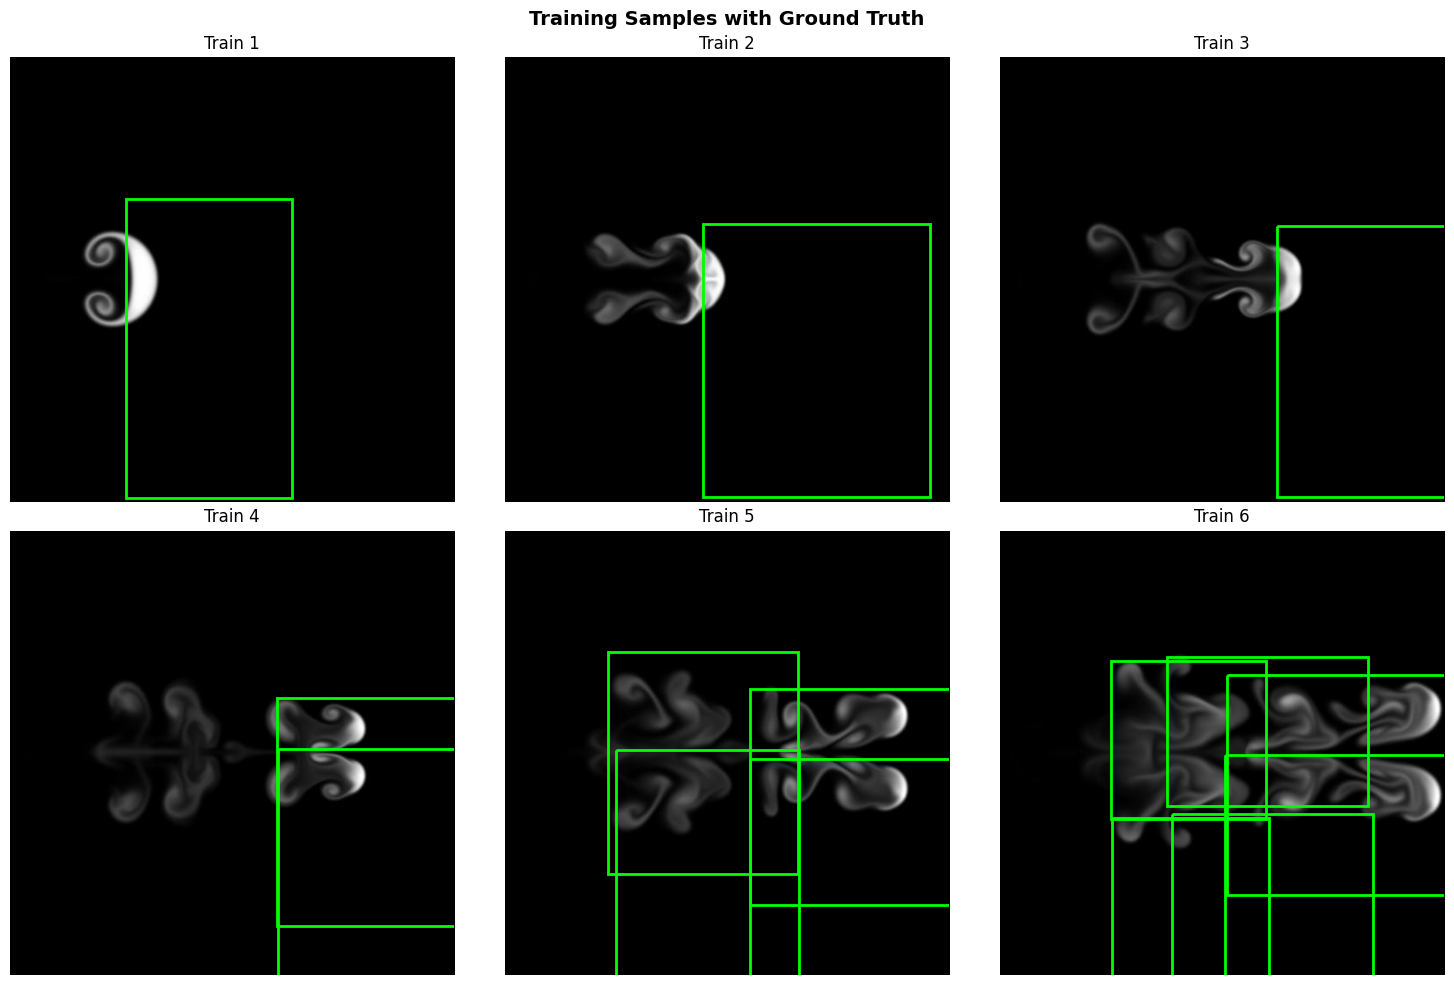

In [7]:
# Show sample training images
train_imgs = sorted(list((YOLO_DATASET_DIR / 'images' / 'train').glob('*.jpg')))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_path in enumerate(train_imgs):
    img = Image.open(img_path)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].axis('off')
    
    # Draw labels
    label_path = str(img_path).replace('images', 'labels').replace('.jpg', '.txt')
    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                clsa, xc, yc, w, h = map(float, line.split())
                img_w, img_h = img.size
                x1 = (xc - w/2) * img_w
                y1 = (yc - h/2) * img_h
                
                rect = plt.Rectangle((x1, y1), w*img_w, h*img_h,
                                    linewidth=2, edgecolor='lime', facecolor='none')
                axes[idx].add_patch(rect)
    
    axes[idx].set_title(f'Train {idx+1}')

plt.suptitle('Training Samples with Ground Truth', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## 7.5. Visualize Augmented Training Data

Show how augmentation transforms the images during training.

Showing 6 augmented versions of: train_000009.jpg
Number of bounding boxes: 12


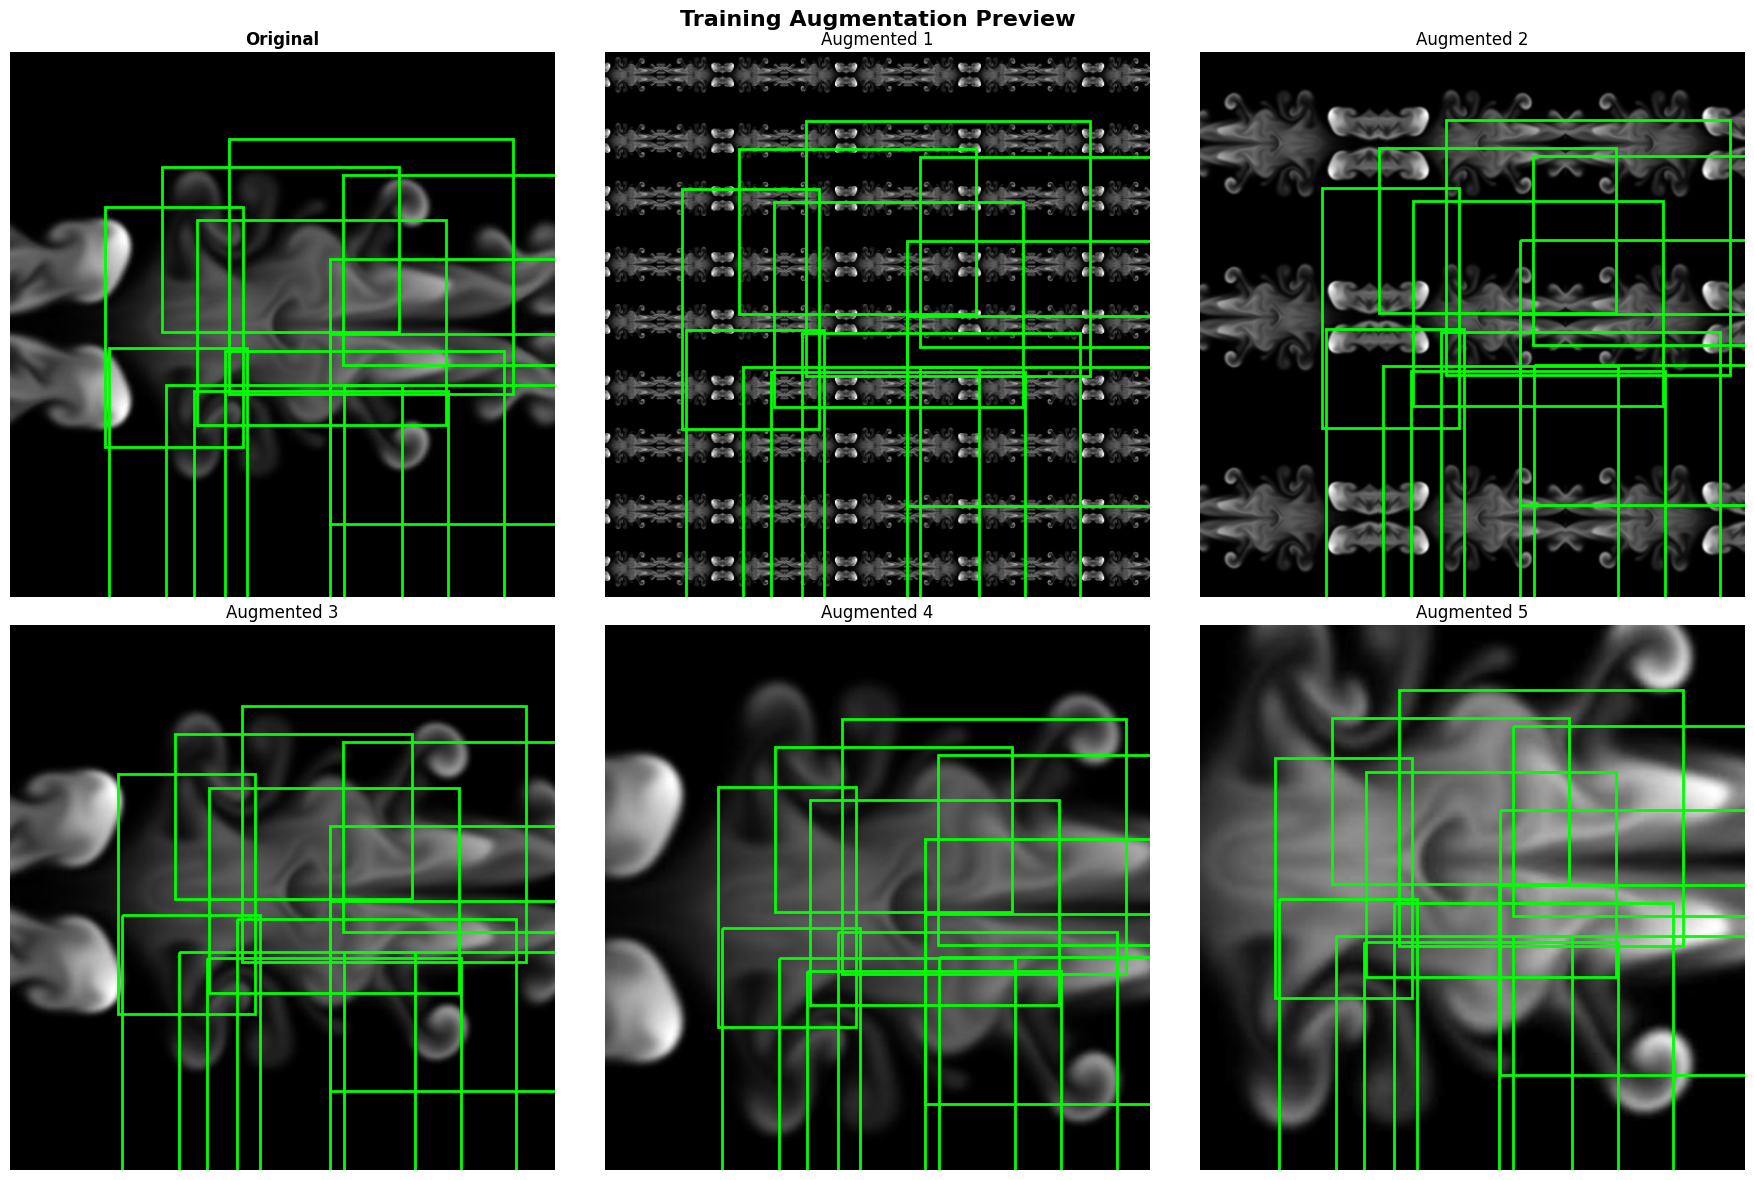


Active augmentation settings during training:
  HSV adjustments: h=0.0, s=0.0, v=0.0
  Rotation: 20°
  Translation: ±5%
  Scale: ±100%
  Horizontal flip: 0% chance
  Vertical flip: 0% chance
  Mosaic augmentation: 50% (combines 4 images)

Note: YOLO will apply these augmentations randomly during training.


In [8]:
# Simulate augmentations by applying them manually
import cv2
from scipy.ndimage import rotate as scipy_rotate

def apply_augmentations_with_boxes(img_array, boxes, seed):
    """Apply random augmentations to both image and bounding boxes."""
    np.random.seed(seed)
    img = img_array.copy()
    h, w = img.shape
    aug_boxes = boxes.copy()
    
    # Track transformations
    flipped_h = False
    flipped_v = False
    tx, ty = 0, 0
    
    # HSV adjustments (on grayscale, simulate brightness/contrast)
    if np.random.rand() < 0.8:
        hsv_v = 1 + (np.random.rand() - 0.5) * 2 * CONFIG['hsv_v']
        img = np.clip(img * hsv_v, 0, 255).astype(np.uint8)
    
    # Horizontal flip
    if np.random.rand() < CONFIG['fliplr']:
        img = np.fliplr(img)
        flipped_h = True
        for i in range(len(aug_boxes)):
            xc, yc, bw, bh = aug_boxes[i]
            aug_boxes[i] = [1 - xc, yc, bw, bh]  # Flip x-center
    
    # Vertical flip
    if np.random.rand() < CONFIG['flipud']:
        img = np.flipud(img)
        flipped_v = True
        for i in range(len(aug_boxes)):
            xc, yc, bw, bh = aug_boxes[i]
            aug_boxes[i] = [xc, 1 - yc, bw, bh]  # Flip y-center
    
    # Translation
    if CONFIG['translate'] > 0:
        tx = int((np.random.rand() - 0.5) * 2 * CONFIG['translate'] * w)
        ty = int((np.random.rand() - 0.5) * 2 * CONFIG['translate'] * h)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        
        # Translate boxes
        for i in range(len(aug_boxes)):
            xc, yc, bw, bh = aug_boxes[i]
            xc_new = xc + tx / w
            yc_new = yc + ty / h
            aug_boxes[i] = [np.clip(xc_new, 0, 1), np.clip(yc_new, 0, 1), bw, bh]
    
    # Scale
    if CONFIG['scale'] > 0:
        scale = 1 + (np.random.rand() - 0.5) * 2 * CONFIG['scale']
        new_h, new_w = int(h * scale), int(w * scale)
        img = cv2.resize(img, (new_w, new_h))
        
        # Crop or pad back to original size
        if scale > 1:
            start_h = (new_h - h) // 2
            start_w = (new_w - w) // 2
            img = img[start_h:start_h+h, start_w:start_w+w]
        else:
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2
            img = np.pad(img, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w)), mode='reflect')
    
    return img, aug_boxes

# Select a sample image with labels
train_imgs = sorted(list((YOLO_DATASET_DIR / 'images' / 'train').glob('*.jpg')))
sample_img_path = train_imgs[np.random.randint(0, min(len(train_imgs), 50))]
sample_img = np.array(Image.open(sample_img_path))

# Load corresponding labels
label_path = str(sample_img_path).replace('images', 'labels').replace('.jpg', '.txt')
original_boxes = []
if Path(label_path).exists():
    with open(label_path) as f:
        for line in f:
            cls, xc, yc, w, h = map(float, line.split())
            original_boxes.append([xc, yc, w, h])

print(f"Showing 6 augmented versions of: {sample_img_path.name}")
print(f"Number of bounding boxes: {len(original_boxes)}")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Show original with boxes
axes[0].imshow(sample_img, cmap='gray')
axes[0].axis('off')
for box in original_boxes:
    xc, yc, bw, bh = box
    img_h, img_w = sample_img.shape
    x1 = (xc - bw/2) * img_w
    y1 = (yc - bh/2) * img_h
    rect = plt.Rectangle((x1, y1), bw*img_w, bh*img_h,
                         linewidth=2, edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect)
axes[0].set_title('Original', fontsize=12, weight='bold')

# Show 5 augmented versions with boxes
for i in range(1, 6):
    aug_img, aug_boxes = apply_augmentations_with_boxes(sample_img, original_boxes.copy(), seed=i*42)
    axes[i].imshow(aug_img, cmap='gray')
    axes[i].axis('off')
    
    # Draw augmented boxes
    for box in aug_boxes:
        xc, yc, bw, bh = box
        img_h, img_w = aug_img.shape
        x1 = (xc - bw/2) * img_w
        y1 = (yc - bh/2) * img_h
        rect = plt.Rectangle((x1, y1), bw*img_w, bh*img_h,
                             linewidth=2, edgecolor='lime', facecolor='none')
        axes[i].add_patch(rect)
    
    axes[i].set_title(f'Augmented {i}', fontsize=12)

plt.suptitle('Training Augmentation Preview', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

print("\nActive augmentation settings during training:")
print(f"  HSV adjustments: h={CONFIG['hsv_h']}, s={CONFIG['hsv_s']}, v={CONFIG['hsv_v']}")
print(f"  Rotation: {CONFIG['degrees']}°")
print(f"  Translation: ±{CONFIG['translate']*100:.0f}%")
print(f"  Scale: ±{CONFIG['scale']*100:.0f}%")
print(f"  Horizontal flip: {CONFIG['fliplr']*100:.0f}% chance")
print(f"  Vertical flip: {CONFIG['flipud']*100:.0f}% chance")
print(f"  Mosaic augmentation: {CONFIG['mosaic']*100:.0f}% (combines 4 images)")
print("\nNote: YOLO will apply these augmentations randomly during training.")

## 8. Train YOLO Model

In [9]:
# Initialize model
print(f"Loading {CONFIG['model']}...")
model = YOLO(CONFIG['model'])

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)
print(f"Device: {CONFIG['device']}")
print(f"Epochs: {CONFIG['epochs']}")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Image size: {CONFIG['img_size']}")
print("="*60 + "\n")

# Train
results = model.train(
    data=str(yaml_path),
    epochs=CONFIG['epochs'],
    batch=CONFIG['batch_size'],
    imgsz=CONFIG['img_size'],
    device=CONFIG['device'],
    workers=CONFIG['workers'],
    patience=CONFIG['patience'],
    save_period=10,
    project=str(OUTPUT_DIR),
    name='detect',
    exist_ok=True,
    pretrained=True,
    optimizer=CONFIG['optimizer'],
    lr0=CONFIG['lr0'],
    weight_decay=CONFIG['weight_decay'],
    verbose=True,
    seed=42,
    deterministic=True,
    single_cls=True,
    cos_lr=True,
    close_mosaic=10,
    amp=True,
    # Augmentation
    hsv_h=CONFIG['hsv_h'],
    hsv_s=CONFIG['hsv_s'],
    hsv_v=CONFIG['hsv_v'],
    degrees=CONFIG['degrees'],
    translate=CONFIG['translate'],
    scale=CONFIG['scale'],
    flipud=CONFIG['flipud'],
    fliplr=CONFIG['fliplr'],
    mosaic=CONFIG['mosaic'],
)

print("\n" + "="*60)
print("✓ TRAINING COMPLETE!")
print("="*60)

Loading yolov10l.pt...

STARTING TRAINING
Device: cuda
Epochs: 500
Batch size: 4
Image size: 1024

New https://pypi.org/project/ultralytics/8.4.14 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.13 🚀 Python-3.11.13 torch-2.10.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=yolo_training_data/config.yaml, degrees=20, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=500, erasing=0.4, exist_ok=True, fliplr=0, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mo

YOLOv10l summary: 365 layers, 25,766,870 parameters, 25,766,854 gradients, 127.2 GFLOPs

Transferred 1015/1027 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 286.8±139.9 MB/s, size: 7.9 KB)
train: Scanning /home/onyxia/work/codalab_tokam2d/yolo_training_data/labels/train... 29 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 29/29 1.2Kit/s 0.0s
train: New cache created: /home/onyxia/work/codalab_tokam2d/yolo_training_data/labels/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 82.2±0.0 MB/s, size: 12.6 KB)
val: Scanning /home/onyxia/work/codalab_tokam2d/yolo_training_data/labels/val... 1 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 366.7it/s 0.0s
val: New cache created: /home/onyxia/work/codalab_tokam2d/yolo_training_data/labels/val.cache
optimizer: Adam(lr=0.0001, momentum=0.937) with parameter groups 167 we

## 9. Evaluate Model

In [10]:
# Validate
model = YOLO(str("runs/detect/runs/detect/weights/best.pt"))
print("Running validation...\n")
metrics = model.val()

print("\nValidation Metrics:")
print("=" * 40)
print(f"  mAP@0.5:      {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"  Precision:    {metrics.box.mp:.4f}")
print(f"  Recall:       {metrics.box.mr:.4f}")
print(f"Intersection Over Union: {metrics.box}")
print("=" * 40)

Running validation...

Ultralytics 8.4.13 🚀 Python-3.11.13 torch-2.10.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10l summary (fused): 174 layers, 24,310,099 parameters, 0 gradients, 120.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 424.9±0.0 MB/s, size: 12.6 KB)
val: Scanning /home/onyxia/work/codalab_tokam2d/yolo_training_data/labels/val.cache... 1 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 466.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.1it/s 0.2s
                   all          1         12       0.56       0.32      0.257     0.0996
Speed: 2.0ms preprocess, 134.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/onyxia/work/codalab_tokam2d/runs/detect/val8

Validation Metrics:
  mAP@0.5:      0.2570
  mAP@0.5:0.95: 0.0996
  Precision:    0.5598
  Recall:       0.3198
Intersection Over Union: ultralytics.utils.metrics.Metric object with attributes:

all

## 10. Visualize Results

In [11]:
results_dir = OUTPUT_DIR / 'detect'

# Training curves
results_img = results_dir / 'results.png'
print("Result dir ", results_dir)
if results_img.exists():
    plt.figure(figsize=(16, 10))
    plt.imshow(Image.open(results_img))
    plt.axis('off')
    plt.title('Training Metrics', fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()

# Confusion matrix
conf_img = results_dir / 'confusion_matrix.png'
if conf_img.exists():
    plt.figure(figsize=(10, 10))
    plt.imshow(Image.open(conf_img))
    plt.axis('off')
    plt.title('Confusion Matrix', fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()

Result dir  runs/detect


## 11. Test on Validation Set

Loaded best model: runs/detect/runs/detect/weights/best.pt

Validation Image: val_000027.jpg
Predicted box: (280.3, 142.9), (511.9, 387.9)
Predicted box: (192.6, 278.9), (499.8, 512.0)
Predicted box: (267.1, 299.8), (511.3, 512.0)
Predicted box: (313.4, 223.3), (512.0, 511.3)
Predicted box: (186.9, 50.5), (445.2, 188.5)
Predicted box: (220.5, 104.8), (506.9, 264.6)
Predicted box: (329.5, 1.0), (512.0, 91.8)
Predicted box: (366.6, 58.0), (511.8, 248.6)
Predicted box: (281.9, 0.0), (511.5, 72.7)
Predicted box: (324.2, 1.1), (512.0, 110.6)
Predicted box: (140.2, 315.8), (341.7, 512.0)
Predicted box: (2.0, 81.5), (232.2, 337.6)
Predicted box: (385.4, 34.4), (512.0, 178.2)
Predicted box: (279.8, 0.3), (511.5, 96.4)
Predicted box: (0.2, 87.1), (102.1, 271.0)


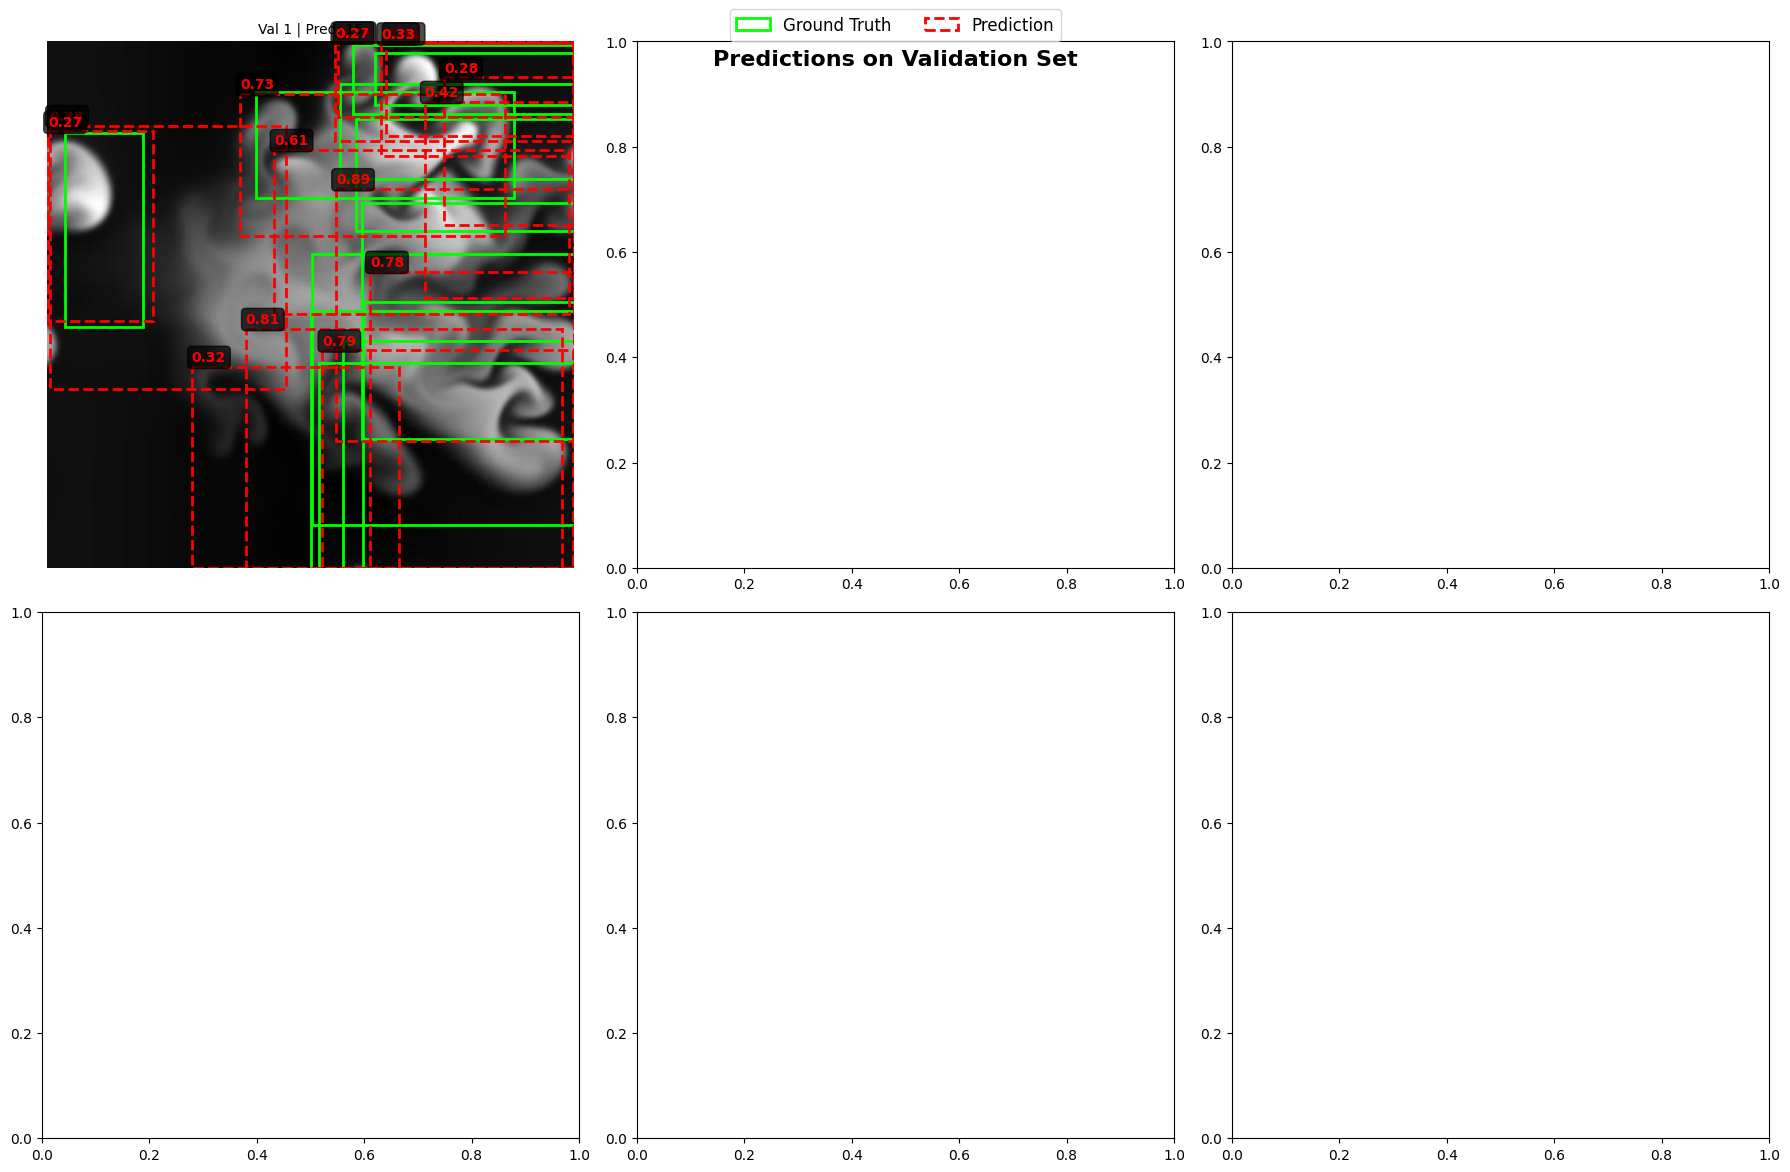

In [12]:
# Load best model
best_model = YOLO(str("runs/detect/runs/detect/weights/best.pt"))
print(f"Loaded best model: runs/detect/runs/detect/weights/best.pt")

# Test on validation samples
val_imgs = sorted(list((YOLO_DATASET_DIR / 'images' / 'val').glob('*.jpg')))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, img_path in enumerate(val_imgs):
    # Predict
    results = best_model(str(img_path), verbose=False)
    
    # Display
    img = Image.open(img_path)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].axis('off')
    
    # Ground truth (green)
    label_path = str(img_path).replace('images', 'labels').replace('.jpg', '.txt')
    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                cls, xc, yc, w, h = map(float, line.split())
                img_w, img_h = img.size
                x1, y1 = (xc - w/2) * img_w, (yc - h/2) * img_h
                
                rect = plt.Rectangle((x1, y1), w*img_w, h*img_h,
                                    linewidth=2, edgecolor='lime', facecolor='none')
                axes[idx].add_patch(rect)
    
    # Predictions (red)
    num_preds = 0
    if len(results[0].boxes) > 0:
        print(f"\nValidation Image: {img_path.name}")
        num_preds = len(results[0].boxes)
        for box in results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            print(f"Predicted box: ({x1:.1f}, {y1:.1f}), ({x2:.1f}, {y2:.1f})")
            conf = box.conf[0].cpu().numpy()
            
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                linewidth=2, edgecolor='red', linestyle='--', facecolor='none')
            axes[idx].add_patch(rect)
            axes[idx].text(x1, y1-5, f'{conf:.2f}', color='red', fontsize=10,
                          weight='bold', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    
    axes[idx].set_title(f'Val {idx+1} | Pred: {num_preds}', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(facecolor='none', edgecolor='lime', linewidth=2, label='Ground Truth'),
    Patch(facecolor='none', edgecolor='red', linewidth=2, linestyle='--', label='Prediction')
]
fig.legend(handles=legend, loc='upper center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, 0.98))

plt.suptitle('Predictions on Validation Set', fontsize=16, weight='bold', y=0.94)
plt.tight_layout()
plt.show()

## 11.5. Test on Training Set

Analyze predictions on training samples to check model fit.

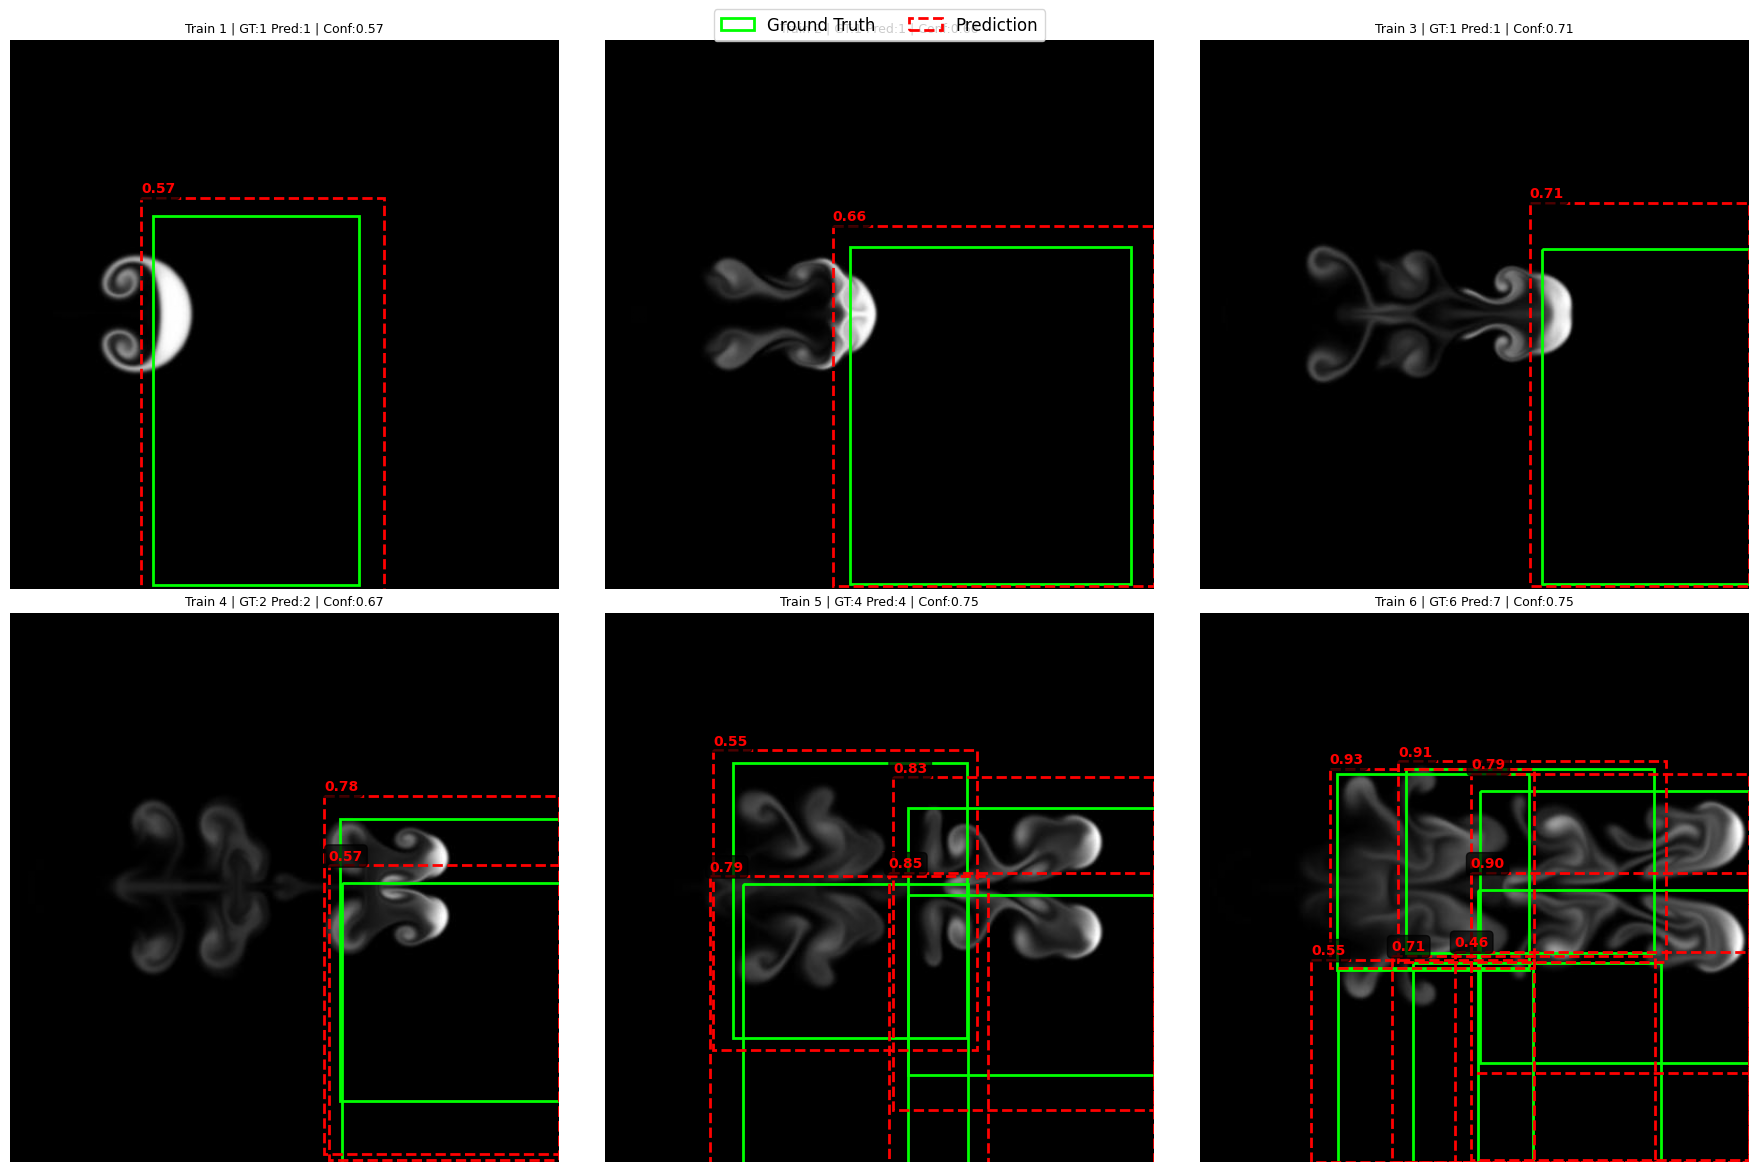


Training Set Predictions:
  Average confidence: 0.722
  Min confidence: 0.461
  Max confidence: 0.930
  Total detections: 16


In [13]:
# Test on training samples to check overfitting
train_imgs = sorted(list((YOLO_DATASET_DIR / 'images' / 'train').glob('*.jpg')))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

train_confidences = []

for idx, img_path in enumerate(train_imgs):
    # Predict
    results = best_model(str(img_path), verbose=False)
    
    # Display
    img = Image.open(img_path)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].axis('off')
    
    # Ground truth (green)
    label_path = str(img_path).replace('images', 'labels').replace('.jpg', '.txt')
    gt_boxes = 0
    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                gt_boxes += 1
                cls, xc, yc, w, h = map(float, line.split())
                img_w, img_h = img.size
                x1, y1 = (xc - w/2) * img_w, (yc - h/2) * img_h
                
                rect = plt.Rectangle((x1, y1), w*img_w, h*img_h,
                                    linewidth=2, edgecolor='lime', facecolor='none')
                axes[idx].add_patch(rect)
    
    # Predictions (red)
    num_preds = 0
    avg_conf = 0
    if len(results[0].boxes) > 0:
        num_preds = len(results[0].boxes)
        for box in results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().numpy()
            train_confidences.append(conf)
            avg_conf += conf
            
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                linewidth=2, edgecolor='red', linestyle='--', facecolor='none')
            axes[idx].add_patch(rect)
            axes[idx].text(x1, y1-5, f'{conf:.2f}', color='red', fontsize=10,
                          weight='bold', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        avg_conf = avg_conf / num_preds if num_preds > 0 else 0
    
    axes[idx].set_title(f'Train {idx+1} | GT:{gt_boxes} Pred:{num_preds} | Conf:{avg_conf:.2f}', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(facecolor='none', edgecolor='lime', linewidth=2, label='Ground Truth'),
    Patch(facecolor='none', edgecolor='red', linewidth=2, linestyle='--', label='Prediction')
]
fig.legend(handles=legend, loc='upper center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, 0.98))

plt.suptitle('Predictions on Training Set', fontsize=16, weight='bold', y=0.94)
plt.tight_layout()
plt.show()

# Statistics
if train_confidences:
    print(f"\nTraining Set Predictions:")
    print(f"  Average confidence: {np.mean(train_confidences):.3f}")
    print(f"  Min confidence: {np.min(train_confidences):.3f}")
    print(f"  Max confidence: {np.max(train_confidences):.3f}")
    print(f"  Total detections: {len(train_confidences)}")
else:
    print("\nNo detections on training samples!")

In [14]:

!pwd

/home/onyxia/work/codalab_tokam2d


## 12. Summary and Model Path

In [15]:
best_path = results_dir / 'weights' / 'best.pt'

print("\n" + "="*70)
print("TRAINING COMPLETE - SUMMARY")
print("="*70)
print(f"\nModel: {CONFIG['model']}")
print(f"Training samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")
print(f"Epochs: {CONFIG['epochs']}")
print(f"\nBest model saved at:")
print(f"  {best_path}")
print(f"\nAll results in: {results_dir}")
print(f"\nTo use in visualization notebook:")
print(f"  trained_model_path = '{best_path}'")
print("\n" + "="*70)


TRAINING COMPLETE - SUMMARY

Model: yolov10l.pt
Training samples: 29
Validation samples: 1
Epochs: 500

Best model saved at:
  runs/detect/weights/best.pt

All results in: runs/detect

To use in visualization notebook:
  trained_model_path = 'runs/detect/weights/best.pt'

